# Esfinge, Gradient Boosting

**Aluno:** Pedro Lucas M. S. de Sá

Bibliotecas utilizadas:

## 1. Introdução

Neste notebook didático será explicado e demonstrado um método de Machine Learning chamado de Gradient Boosting.

### 1.1 Objetivo

O objetivo por trás desse notebook é ensinar como o Gradient Boosting funciona tanto na forma de construção do modelo utilizando de modelos mais simples para realizar uma correção nos erros e ir melhorando os modelos a cada passagem até chegar em um modelo final que faz a predição.

### 1.2 Conhecimentos prévios

É esperado que o leitor desse notebook didático saiba o conceito básico de Machine Learning, entenda diferença entre atributos (features) e variável alvo (target), ideia de treinamento e teste, noções de regressão e classificação, funcionamento básico de uma árvore de decisão e noções de Random Forest.

### 1.3 Organização do notebook

Será abordado como funciona árvore de decisão, aprendizado em ensemble, boosting, correção sequencial, função de perda, gradiente e por fim gradient boosting.

## 2. Relembrando alguns conceitos

Nessa seção irei rever de forma breve alguns conceitos.

### 2.1 Features e target

Os atributos (features) são as características do conjunto de dados que entram no modelo e vão servir para prever a variável alvo (target).

### 2.2 Treinamento e predição

O treinamento é a passagem de dados pelo modelo onde ele aprende uma relação entre as features e o target, assim ele pode prever um target, a partir de novas features.

### 2.3 Erro de uma predição

Após o treinamento ao realizar-se uma previsão de target com algumas features, temos um erro envolvido se compararmos com o valor do target real.

Um exemplo:

$ \text{Target real} = 100$

$ \text{Target previsto} = 90$

$ \text{Erro} = \text{?}$

O erro pode ser calculado de diversas formas como sendo o erro absoluto que é o modulo da diferença entre os targets, pode ser o erro relativo que é calculado pelo modulo da diferença dividido pelo valor real dos targets ou até o erro quadrático que é o quadrado da diferença dos targets. Assim existem diversas formas de analisar o erro.

$ \text{Erro}_{\text{Absoluto}} = |100-90| = 10$

$ \text{Erro}_{\text{Relativo}} = \dfrac{|100-90|}{100} = 0,1$

$ \text{Erro}_{\text{Quadrático}} = (100-90)^2 = 100$


## 3. Árvores de decisão

Árvores de decisão são uma forma de tentar prever um resultado utilizando uma série de tomadas de decisão, como mostra abaixo uma árvore de decisão que ilustra como é realizado a escolha de uma fruta com base em suas características.

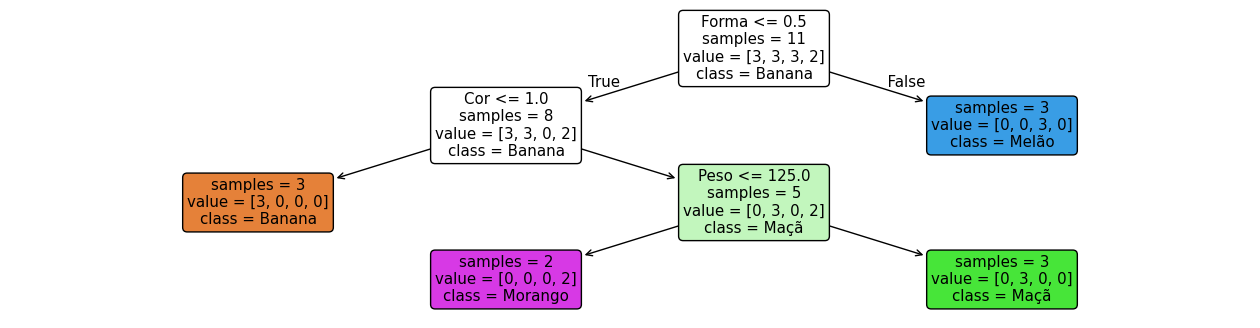

`Imagem: Árvore de decisão de uma fruta disponível em https://elisaterumi.substack.com/p/arvore-de-decisao-como-tomar-decisoes`.

As árvores de decisão realizam sua previsão com base nos valores das features até chegar em uma folha, onde produz a previsão.

Árvores de decisão podem ser instáveis ​​porque pequenas variações nos dados podem gerar uma árvore completamente diferente. Uma possibilidade de evitar essa instabilidade de uma única árvore é utilizando um ensemble que gera um modelo mais robusto, com a combinação de diferentes modelos, produzindo uma previsão conjunta.

## 4. Ensemble Learning

O ensemble é uma técnica em que utiliza-se de diferentes modelos para conseguir criar uma previsão final. Em que para a criação desses modelos você pode utilizar de bagging ou boosting.

O bagging constrói vários modelos independentes entre si para depois combiná-los e obter uma previsão final combinando todos os modelos. Um exemplo de método que utiliza bagging é Random Forest.

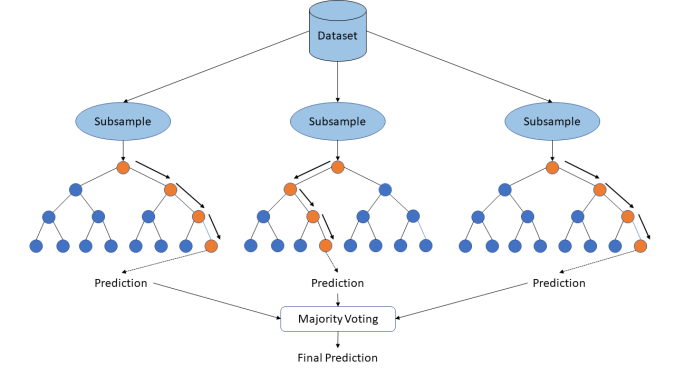

`Imagem 2: Ilustração de um modelo Random Forest que utiliza de árvores de decisão, que combinando a previsão de cada árvore resulta em uma previsão final. Disponível em https://www.researchgate.net/figure/Random-Forest-Algorithm-Dataset-is-split-into-subsamples-and-each-tree-like-structure_fig2_345362070`

Já um modelo construído a partir de boosting, o resultado de um modelo influencia a construção do próximo modelo, de forma que se busca corrigir o erro presente nos modelos anteriores. Um exemplo de método que utiliza de boosting é o gradient boosting.

| Característica        | Bagging                          | Boosting                               |
| ---                   | ---                              | ---                                    |
| Construção            | Independente                     | Sequencial                             |
| Relação entre modelos | Não dependem dos anteriores      | Próximo modelo considera os anteriores |
| Objetivo              | Combinar as previsões dos modelos| Melhorar progressivamente as previsões |
| Exemplo               | Random Forest                    | Gradient Boosting                      |

## 5. Gradient Boosting

De forma introdutória ao gradient boosting, o método identifica qual é a distância do objetivo com a previsão, e realiza um tipo de correção, com o modelo seguinte.

### Exemplo didático

   Nesse exemplo mostro de forma intuitiva como funciona o gradient boosting.

   $\text{Valor Real} = 50$

   $\text{Previsão do modelo} = 45$

   O próximo modelo teria a previsão atual e adicionaria uma correção com um novo modelo nesse exemplo sendo um valor próximo de $5$, resultando em uma nova previsão mais próxima do objetivo.

   $\text{Nova previsão} = \text{Previsão inicial} + \text{Correção}$

   $\text{Nova previsão} = 45 + 5 = 50$

### Função de perda

A função de perda serve para identificar o quão ruim a previsão está em relação ao objetivo, uma das formas de-se identificar é analisando o erro presente da predição que foi comentado na seção (2.3), uma forma de encontrar esse erro com gradient boosting é utilizando do erro quadrático médio(MSE). 

N: número de observações;

$O_i$: valor observado/real da observação $i$;

$P_i$: valor previsto pelo modelo para a observação $i$.

$ \text{MSE} = \dfrac{\sum_{i=1}^{N}( \text{O}_i - \text{P}_i )^2}{N}$

Mas agora existe um problema, o que devemos fazer com esse valor obtido do MSE, pois ele só diz o quanto erramos e não informa a direção do erro.

### Gradiente

O gradiente serve para identificar como a função de perca cresce, para ter a minimização da perda é necessário ir na direção oposta ao gradiente, assim podendo realizar uma correção da previsão com a função de perda.

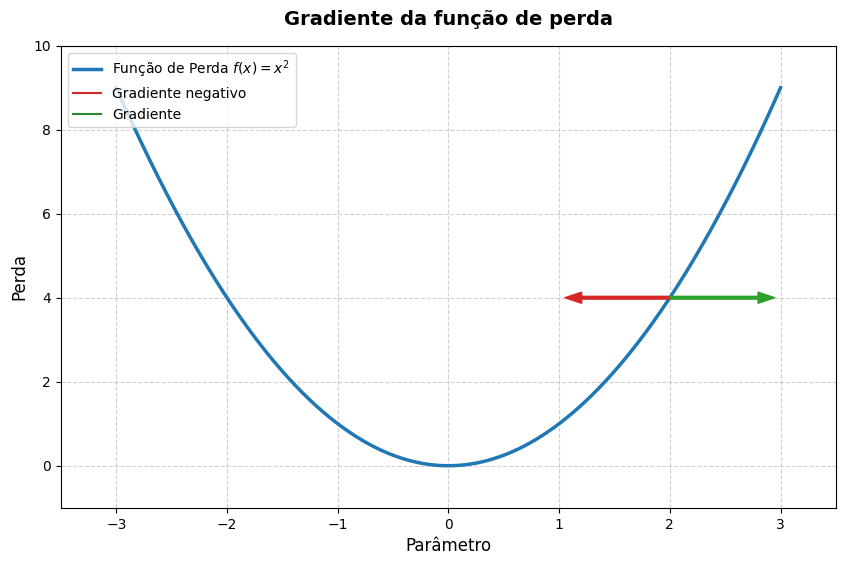
`Imagem 3: Gráfico ilustrativo do gradiente para a função de perda de autoria própria`

### Construção sequencial

A sequencial dos processos que é realizada é a seguinte, é realizada uma previsão inicial com um modelo, após isso se calcula a perda para o valor da correção e o gradiente negativo para a direção de correção, se treina o modelo um novo modelo para representar essa correção, adiciona a contribuição desse modelo ao já existente, e se repete o processo.

A equação que mostra esse processo é a seguinte:

$F_m(x)$: Predição do modelo novo com feature $x$.

$F_{m-1}(x)$: Predição do modelo antigo com feature $x$.

$η$: Peso da correção.

$h_m(x)$: Correção do novo modelo.

$F_m(x)=F_{m−1}(x)+ηh_m(x)$

### Atualização do modelo







## 6. Hiperparâmetros

   <!-- 
   - número de árvores
   - learning rate
   - profundidade
   - overfitting/underfitting
   -->

## 7. Aplicação ao Go
   
   <!-- 
   - Dataset
   - Como uma partida vira exemplos de treinamento
   - Features
   - Target: qualidade da jogada
   -->

## 8. Treinamento do modelo

## 9. Avaliação

## 10. Comparação

   <!-- 
   - Gradient Boosting × Random Forest
   - eventualmente Ridge
   -->

## 11. Visualizações e análise

## 12. Conclusão

## 13. Descrição do uso de IA

## 14. Referências

2. https://scikit--learn-org.translate.goog/stable/modules/tree.html?_x_tr_sl=en&_x_tr_tl=pt&_x_tr_hl=pt&_x_tr_pto=tc
